In [28]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation=None, model_path='./output/mirt_model_k19_auc89.pt')

# varimax, oblimax, quartimax, equamax, geomin_ort, promax, oblimin, quartimin, geomin_obl

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

a_df_scenarios = pd.DataFrame(a, index=resmat.columns.get_level_values('scenario'), columns=factor_names)
# Group by similar index values and calculate mean
a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_23397/81466236.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()


In [30]:
from sklearn.decomposition import PCA
import numpy as np

# theta is your factor score matrix
pca = PCA(n_components=1)
g_scores = pca.fit_transform(theta)[:, 0]  # general composite

In [31]:
with pd.option_context('display.max_rows', 10):
  print(pd.DataFrame(g_scores, index=resmat.index, columns=['g_score']).sort_values(by='g_score', ascending=False))

                                           g_score
request.model                                     
deepseek-ai/deepseek-v3                   3.357121
meta/llama-3.2-90b-vision-instruct-turbo  3.267058
meta/llama-3.1-70b-instruct-turbo         3.019625
meta/llama-3.1-405b-instruct-turbo        2.960796
meta/llama-3.3-70b-instruct-turbo         2.935962
...                                            ...
ai21/j1-grande-v2-beta                   -3.949758
ai21/j1-grande                           -4.004394
tiiuae/falcon-7b                         -4.245142
tiiuae/falcon-7b-instruct                -4.381553
openai/text-babbage-001                  -4.636945

[183 rows x 1 columns]


In [32]:
# CONCISE REPLACEMENT using load_rotate_on_pc.py
import sys
sys.path.append('.')
import pandas as pd
from load_rotate_on_pc import load_and_rotate_pc1_reckase, load_and_rotate_pc1_targeted

resmat = pd.read_pickle("../data/resmat.pkl")

# Extract names for labeling
item_names = resmat.columns.get_level_values('input.text').to_list()
model_names = resmat.index.to_list()

df_theta = pd.DataFrame(theta, index=model_names, columns=factor_names)
df_a = pd.DataFrame(a, index=resmat.columns.get_level_values('scenario'), columns=factor_names)

df_theta, df_a, top_items_df, Q_final = load_and_rotate_pc1_reckase(
    model_path='./output/mirt_model_k19_auc89.pt',
    top_k=20,
    model_names=model_names,
    item_names=item_names
)

print("Targeted rotation complete! Results cached and factor signs flipped for interpretability.")
print(f"Theta shape: {df_theta.shape}")
print(f"A shape: {df_a.shape}")
print(f"Top items per factor: {len(top_items_df)} factors")
df_theta['F1'] = -df_theta['F1'] + 3
df_theta.sort_values(by='F1', ascending=False)

Targeted rotation complete! Results cached and factor signs flipped for interpretability.
Theta shape: (183, 19)
A shape: (78712, 19)
Top items per factor: 19 factors


/Users/ronan/Developer/reeval-multi/mirt-official/load_rotate_on_pc.py:212: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(model_path, map_location=to

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19
deepseek-ai/deepseek-v3,6.936767,0.056104,0.710098,-0.866894,0.307594,-0.593585,1.144064,-0.288692,0.712433,1.660656,1.073084,-0.080964,-0.302620,0.615778,-0.271398,0.004565,0.365617,0.262609,0.284055
meta/llama-3.2-90b-vision-instruct-turbo,6.846704,0.194719,0.695831,-0.641237,0.657229,0.223510,1.047119,0.133915,1.388605,0.365853,0.188570,-0.416119,0.502169,1.719404,-0.034200,-0.124045,0.950639,0.663119,-0.703346
meta/llama-3.1-70b-instruct-turbo,6.599271,0.219458,0.763797,-0.570470,0.372732,0.135509,1.133381,0.317554,1.582186,0.676870,0.566260,-0.684477,-0.059751,1.590262,-0.294355,-0.029269,0.592052,0.812736,-0.526358
meta/llama-3.1-405b-instruct-turbo,6.540441,-0.146486,-0.239799,-0.429043,1.294781,0.899659,0.563422,0.376783,1.380559,0.501545,0.089549,0.464182,0.085300,0.901701,0.205802,0.664336,1.147804,0.433361,0.531038
meta/llama-3.3-70b-instruct-turbo,6.515608,0.571507,-0.207456,-0.439777,0.900549,-0.089143,0.200241,0.165233,0.681023,0.069631,-0.099404,-0.005928,0.514733,1.442190,-0.219649,-0.022077,0.854954,0.917302,-0.995496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ai21/j1-grande-v2-beta,-0.370109,1.476085,0.400128,0.515565,1.350668,0.484247,1.608759,-0.386585,1.011896,1.864670,2.038809,0.918542,-0.164122,1.177611,1.053339,0.941061,0.118066,-0.091517,-0.387881
ai21/j1-grande,-0.424745,0.869392,0.676259,-0.319962,0.719766,0.566027,0.774221,0.107264,0.170495,0.297554,-0.473289,0.172366,0.714645,0.817550,0.618305,1.693815,0.916714,0.620020,-0.850425
tiiuae/falcon-7b,-0.665491,0.681826,-0.348140,-0.452142,1.311324,-0.052221,0.482921,0.010860,0.970925,0.646479,0.717377,0.045905,0.060641,1.672649,0.639623,0.485112,1.022776,0.257667,0.914701
tiiuae/falcon-7b-instruct,-0.801904,0.552795,-0.303720,-0.232221,1.751495,-0.221591,0.263987,0.297197,1.179330,0.782821,0.656708,0.631821,0.185035,1.308935,0.177994,0.546147,1.196865,0.730137,1.147559


In [33]:
top_k = 20  # Top items per scenario
loading_threshold = 0.1  # Minimum absolute loading for scenarios

a_df_questions = pd.DataFrame(df_a.values, index=resmat.columns.get_level_values('input.text'), columns=factor_names)

for col in a_df_questions.columns:
    with open('./output/factor_loadings_analysis_'+col+'.txt', 'w', encoding='utf-8') as f:
        f.write('='*80 + '\n')
        f.write(f'TOP LOADING ITEMS FOR FACTOR {col} (by Scenario)\n')
        f.write(f'Only scenarios with absolute loading > {loading_threshold}\n')
        f.write('='*80 + '\n')
        
        # Get scenarios with absolute loading > threshold
        qualifying_scenarios = a_df_grouped[abs(a_df_grouped[col]) > loading_threshold].index
        # Split into positive and negative scenarios
        pos_scenarios = a_df_grouped.loc[qualifying_scenarios, col][a_df_grouped.loc[qualifying_scenarios, col] > 0]
        neg_scenarios = a_df_grouped.loc[qualifying_scenarios, col][a_df_grouped.loc[qualifying_scenarios, col] < 0]
        # Sort positive from highest to lowest, negative from lowest to highest
        pos_scenarios_sorted = pos_scenarios.sort_values(ascending=False)
        neg_scenarios_sorted = neg_scenarios.sort_values(ascending=True)
        # Concatenate for display: positives first, then negatives
        scenario_loadings = pd.concat([pos_scenarios_sorted, neg_scenarios_sorted])

        f.write(f'\n📊 QUALIFYING SCENARIOS ({len(qualifying_scenarios)} total):\n')
        f.write('-'*50 + '\n')
        
        if len(qualifying_scenarios) == 0:
            f.write(f'No scenarios meet the threshold (|loading| > {loading_threshold})\n')
            f.write(f'Consider lowering the threshold or check factor loadings.\n\n')
            f.write('='*80 + '\n\n')
            continue
        
        for scenario, loading in scenario_loadings.items():
            f.write(f'{scenario}: {loading:.4f}\n')
        
        f.write('\n' + '='*80 + '\n')
        
        # For each qualifying scenario, get top loading questions
        for scenario in scenario_loadings.index:
            scenario_loading = scenario_loadings[scenario]
            
            # Get questions from this scenario
            scenario_mask = resmat.columns.get_level_values('scenario') == scenario
            scenario_questions = resmat.columns[scenario_mask].get_level_values('input.text')
            
            # Filter a_df_questions for this scenario
            scenario_question_loadings = a_df_questions.loc[scenario_questions, col].dropna()
            
            if len(scenario_question_loadings) == 0:
                continue
                
            f.write(f'\n🎯 SCENARIO: {scenario} (Factor Loading: {scenario_loading:.4f})\n')
            f.write('='*60 + '\n')
            
            # Get top positive or negative loadings for this scenario, and sort accordingly
            if scenario_loading > 0:
                # Sort from highest to lowest for positive section
                top_items = scenario_question_loadings.sort_values(ascending=False).head(top_k)
                f.write(f'📈 TOP {min(top_k, len(top_items))} POSITIVE LOADING ITEMS:\n')
            else:
                # Sort from lowest to highest for negative section
                top_items = scenario_question_loadings.sort_values(ascending=True).head(top_k)
                f.write(f'📉 TOP {min(top_k, len(top_items))} NEGATIVE LOADING ITEMS:\n')
            
            f.write('-'*40 + '\n')
            
            for i, (question, loading) in enumerate(top_items.items(), 1):
                f.write(f'\n{i}. [[[Loading]]]: {loading:.4f}\n')
                f.write(f'   [[[Question]]]: {question}\n')
            
            f.write('\n' + '-'*60 + '\n')
        
        # Overall statistics
        f.write(f'\n📊 OVERALL STATISTICS FOR {col}:\n')
        f.write('-'*40 + '\n')
        f.write(f'Total scenarios analyzed: {len(qualifying_scenarios)}\n')
        f.write(f'Scenarios filtered out (|loading| <= {loading_threshold}): {len(a_df_grouped) - len(qualifying_scenarios)}\n')
        
        if len(scenario_loadings) > 0:
            f.write(f'Strongest scenario: {scenario_loadings.iloc[0]:.4f} ({scenario_loadings.index[0]})\n')
            f.write(f'Average absolute loading: {abs(scenario_loadings).mean():.3f}\n')
        else:
            f.write('No qualifying scenarios to analyze.\n')
        
        f.write('\n' + '='*80 + '\n\n')

print("Factor loadings analysis saved to individual files per factor")

Factor loadings analysis saved to individual files per factor


Original a_df shape: (78712, 19)
Grouped a_df shape: (22, 19)
Number of unique scenarios: 22


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_23397/1073814106.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()


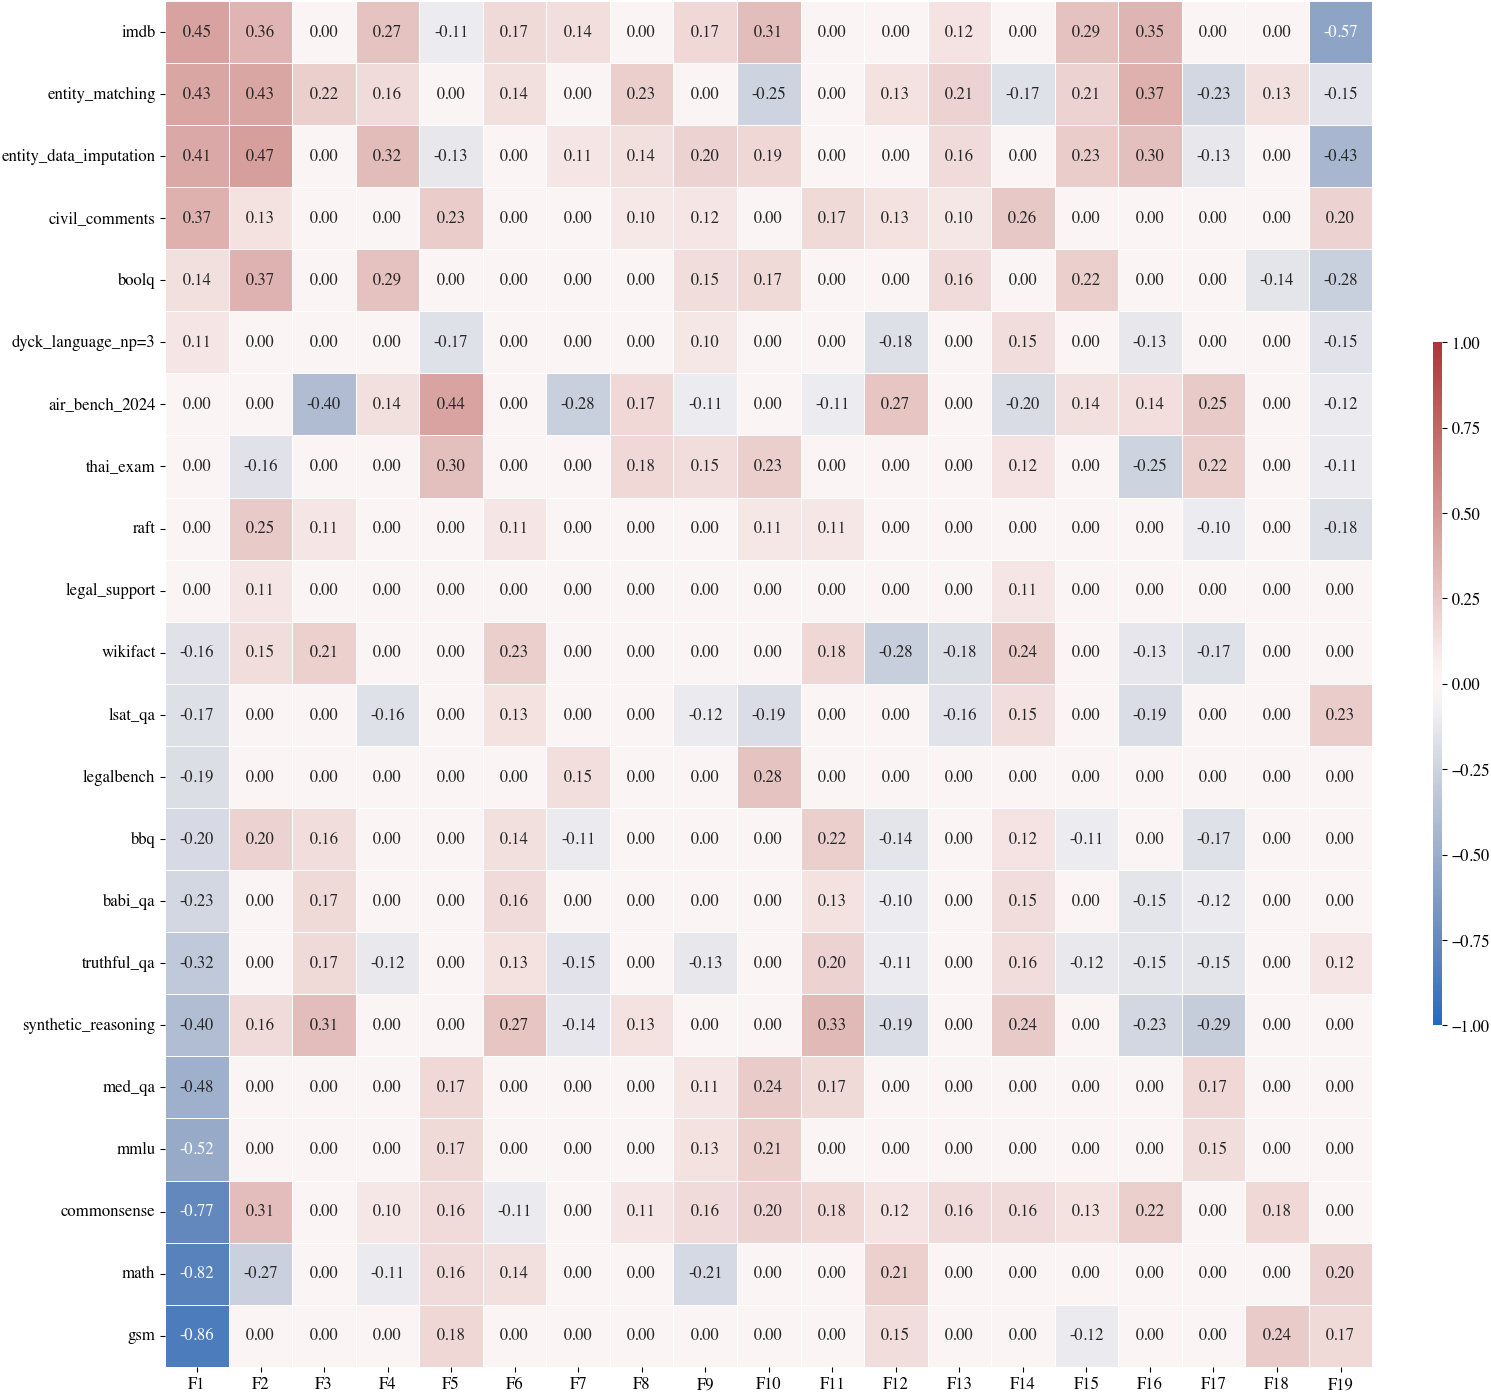

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

factor_names = [f'F{i+1}' for i in range(df_a.shape[1])]

a_df_scenarios = pd.DataFrame(df_a.values, index=resmat.columns.get_level_values('scenario'), columns=factor_names)
# Group by similar index values and calculate mean
a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()

# Check the resulting shape
print(f"Original a_df shape: {a_df_scenarios.shape}")
print(f"Grouped a_df shape: {a_df_grouped.shape}")
print(f"Number of unique scenarios: {len(a_df_grouped.index)}")

inspection = a_df_grouped.copy()
inspection[abs(inspection) < 0.1] = 0

# 1. Order rows by sum (scenarios with highest total loadings first) 
# row_sums = inspection.abs().sum(axis=1)
# row_order = row_sums.sort_values(ascending=False).index

# 2. Reorder inspection matrix - only reorder rows, keep columns in original order
# ordered_inspection = inspection.loc[row_order, :]
ordered_inspection = inspection.sort_values(by='F1', ascending=False)

# You can adjust figsize to make the plot larger or smaller for better readability.
fig, ax = plt.subplots(figsize=(15, 14))

# 2. Generate the clustered heatmap
# sns.heatmap is the core function here.
sns.heatmap(
    ordered_inspection,     # The clustered data to plot
    annot=True,       # Write the data value in each cell
    fmt=".2f",        # Use two decimal places for annotations
    cmap='vlag',  # Use the 'vlag' color map (blue-white-red)
    linewidths=.5,    # Add lines between cells
    ax=ax,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'shrink': 0.5, 'aspect': 75}
)

# 3. Add titles and labels for clarity
ax.set_xlabel('')
ax.set_ylabel('')

# 4. Ensure labels are not cut off
# plt.tight_layout()

# 5. Display the plot
plt.show()

# To save the figure to a file, uncomment the line below
fig.savefig('../result/clustered_heatmap_.pdf', bbox_inches='tight')

In [35]:
import pandas as pd

# Standardize residuals (F2...F19), keep F1 as-is
theta_std = df_theta.copy()
for col in df_theta.columns[1:]:  # skip F1
    theta_std[col] = (df_theta[col] - df_theta[col].mean()) / df_theta[col].std()

# Build composite scores: F1 + standardized Fj
scores = {}
scores['score_1'] = pd.Series(df_theta['F1'], index=resmat.index)

for j in range(2, 20):  # F2 to F19
    scores[f'score_{j}'] = pd.Series(
        df_theta['F1'] + theta_std[f'F{j}'],
        index=resmat.index
    )

# Convert to DataFrame if you want a single table
scores_df = pd.DataFrame(scores)


In [36]:
# Assuming 'resmat' is your DataFrame where rows represent test-takers

# 1. Count the NaN values for each row (test-taker)
nan_counts = resmat.isnull().sum(axis=1)

# 2. Sort the results to find the test-takers with the least NaNs
sorted_nan_counts = nan_counts.sort_values()

# 3. Select the top 10 and print the result
top_10_with_least_nan = sorted_nan_counts.head(100)

with pd.option_context('display.max_rows', None):
  print(top_10_with_least_nan)

request.model
openai/gpt-3.5-turbo-0613                    2295
meta/llama-2-7b                              7280
mistralai/mistral-7b-v0.1                    7280
meta/llama-2-13b                             7280
meta/llama-2-70b                             7280
AlephAlpha/luminous-extended                18765
openai/text-davinci-002                     18765
openai/text-davinci-003                     18765
AlephAlpha/luminous-supreme                 18765
ai21/j2-grande                              18765
AlephAlpha/luminous-base                    18765
ai21/j2-jumbo                               18765
openai/gpt-3.5-turbo-0301                   20444
tiiuae/falcon-7b                            20503
meta/llama-65b                              20503
tiiuae/falcon-40b                           20503
openai/text-curie-001                       23691
openai/text-ada-001                         23691
openai/text-babbage-001                     23691
cohere/medium-20221108              

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_23397/663843420.py:208: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


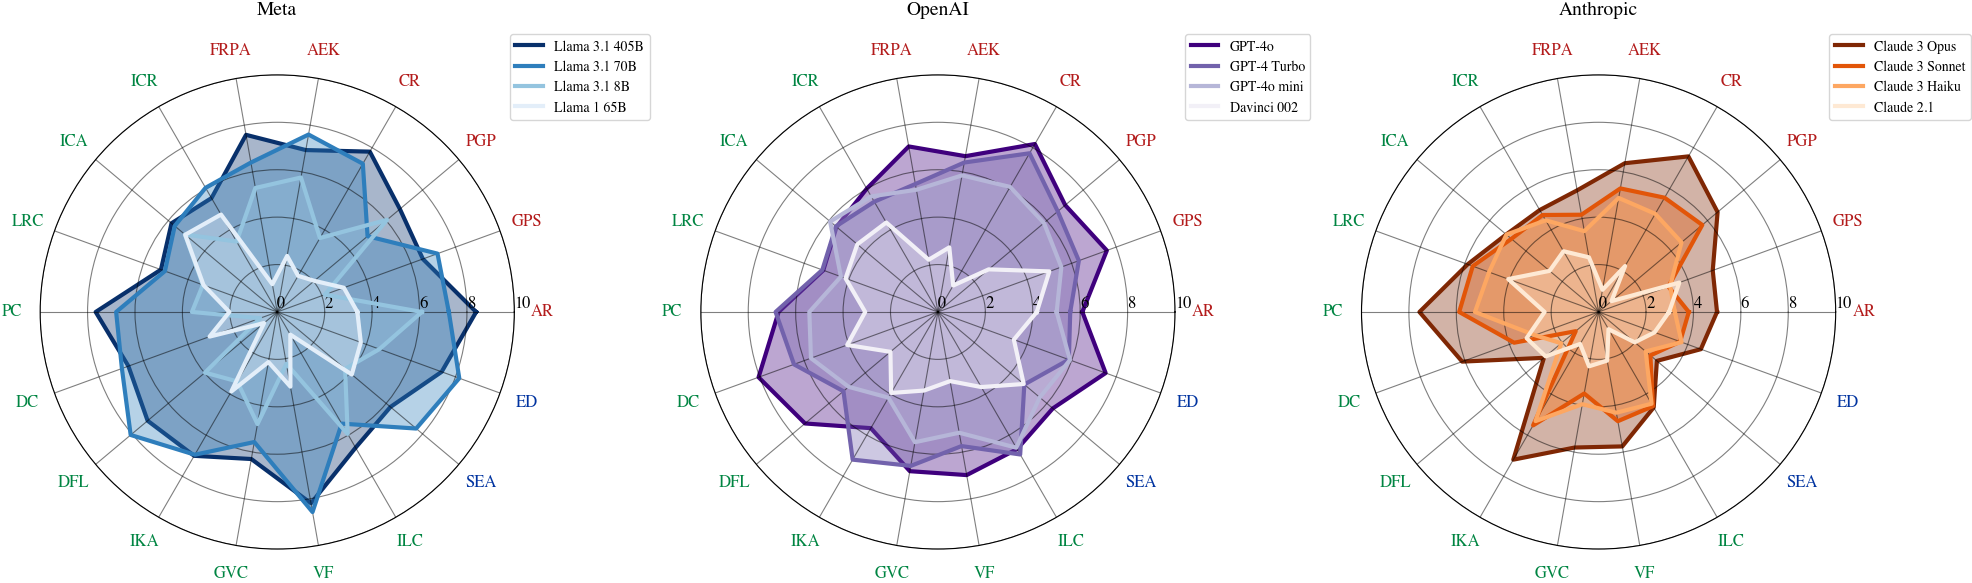

Selected models for radar charts:

META:
  Llama 3.1 405B
  Llama 3.1 70B
  Llama 3.1 8B
  Llama 1 65B

OPENAI:
  GPT-4o
  GPT-4 Turbo
  GPT-4o mini
  Davinci 002

ANTHROPIC:
  Claude 3 Opus
  Claude 3 Sonnet
  Claude 3 Haiku
  Claude 2.1


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import pi
import sys
sys.path.append('..')
import style
plt.rcParams.update(style.rcparams)

common_indices = [
    'anthropic/claude-3-sonnet-20240229', 'anthropic/claude-3-opus-20240229', 'anthropic/claude-3-haiku-20240307', 'anthropic/stanford-online-all-v4-s3',
    'meta/llama-3.1-8b-instruct-turbo', 'meta/llama-3.1-70b-instruct-turbo', 'meta/llama-3.1-405b-instruct-turbo', 'meta/llama-65b',
    'openai/gpt-4o-2024-05-13', 'openai/gpt-4o-mini-2024-07-18', 'openai/gpt-4-turbo-2024-04-09', 'openai/text-davinci-002'
]

# EDIT: Added a mapping from code names to formal display names
model_name_mapping = {
    'anthropic/claude-3-sonnet-20240229': 'Claude 3 Sonnet',
    'anthropic/claude-3-opus-20240229': 'Claude 3 Opus',
    'anthropic/claude-3-haiku-20240307': 'Claude 3 Haiku',
    'anthropic/stanford-online-all-v4-s3': 'Claude 2.1',
    'meta/llama-3.1-8b-instruct-turbo': 'Llama 3.1 8B',
    'meta/llama-3.1-70b-instruct-turbo': 'Llama 3.1 70B',
    'meta/llama-3.1-405b-instruct-turbo': 'Llama 3.1 405B',
    'meta/llama-65b': 'Llama 1 65B',
    'openai/gpt-4o-2024-05-13': 'GPT-4o',
    'openai/gpt-4o-mini-2024-07-18': 'GPT-4o mini',
    'openai/gpt-4-turbo-2024-04-09': 'GPT-4 Turbo',
    'openai/text-davinci-002': 'Davinci 002'
}


scores_mapping = {
    # 'F1': scores['score_1'],
    'F2': scores['score_2'],
    'F3': scores['score_3'],
    'F4': scores['score_4'],
    'F5': scores['score_5'],
    'F6': scores['score_6'],
    'F7': scores['score_7'],
    'F8': scores['score_8'],
    'F9': scores['score_9'],
    'F10': scores['score_10'],
    'F11': scores['score_11'],
    'F12': scores['score_12'],
    'F13': scores['score_13'],
    'F14': scores['score_14'],
    'F15': scores['score_15'],
    'F16': scores['score_16'],
    'F17': scores['score_17'],
    'F18': scores['score_18'],
    'F19': scores['score_19'],
}

skill_scores = pd.DataFrame(scores_mapping)

# Psychometric Groupings of AI Capability Dimensions

reasoning = {
    'F6': ('Abstract Reasoning', 'AR'),
    'F11': ('General Problem Solving', 'GPS'),
    'F12': ('Procedural and Generative Planning', 'PGP'),
    'F17': ('Complex Reasoning', 'CR'),
    'F18': ('Application of External Knowledge', 'AEK'),
    'F19': ('Formal Reasoning and Procedural Adherence', 'FRPA')
}

comprehension = {
    'F2': ('In-Context Retrieval', 'ICR'),
    'F13': ('In-Context Analysis', 'ICA'),
    'F4': ('Literal Reading Comprehension', 'LRC'),
    'F5': ('Procedural Comprehension', 'PC'),
    'F10': ('Descriptive Comprehension', 'DC'),
    'F7': ('Dense and Formal Language Comprehension', 'DFL'),
    'F8': ('Internal Knowledge and Application', 'IKA'),
    'F15': ('General Verbal Comprehension', 'GVC'),
    'F9': ('Verbal Fluency', 'VF'),
    'F16': ('Informal Language Comprehension', 'ILC')
}

style = {
    'F3': ('Safet and Ethics Alignment', 'SEA'),
    'F14': ('Expansive Discourse', 'ED')
}

# --- START OF CHANGE 1: Define colors and map skills to groups ---

# 1. Define a color for each capability group
group_colors = {
    "Reasoning": '#B31B1B',
    "Comprehension": '#008542',
    "Style": '#0033A0'
}

# 2. Create a reverse map from a skill ('F2') to its group name
skill_to_group_map = {}
for group_name, skills_dict in {
    "Reasoning": reasoning,
    "Comprehension": comprehension,
    "Style": style
}.items():
    for skill_code in skills_dict:
        skill_to_group_map[skill_code] = group_name



all_capability_dims = {
    **reasoning,
    **comprehension,
    **style
}

skill_scores = skill_scores[list(all_capability_dims.keys())]
abbreviated_labels = [all_capability_dims[col][1] for col in skill_scores.columns]


# 3. Create a list of colors that matches the order of the labels
label_colors = [group_colors[skill_to_group_map[col]] for col in skill_scores.columns]


skill_scores = skill_scores.loc[common_indices]


# 4. Update the function to accept and apply label colors
def create_radar_chart(data, labels, title, ax, colors=None, model_names=None, label_colors=None):
    N = len(labels)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(data)))
    for i, (model_data, color) in enumerate(zip(data, colors)):
        values = model_data.tolist()
        values += values[:1]
        model_name = model_names[i] if model_names else f'Model {i+1}'
        display_name = model_name.split('/')[-1] if '/' in model_name else model_name
        ax.plot(angles, values, '-', linewidth=3, label=display_name, color=color, alpha=1, zorder=i + 1)
        ax.fill(angles, values, color=color, alpha=0.35)
    ax.tick_params(pad=10)
    range_ax = range(0, 11, 2)
    ax.set_ylim(range_ax[0], range_ax[-1])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=12, weight='bold')
    
    # This is the new part: Apply the colors to the tick labels
    if label_colors:
        for xtick, color in zip(ax.get_xticklabels(), label_colors):
            xtick.set_color(color)
            
    ax.grid(True, alpha=0.5, color='black')
    ax.set_rgrids(range_ax, angle=0, labels=range_ax, fontsize=12)
    ax.set_rmin(range_ax[0])



companies = { 'meta': [], 'openai': [], 'anthropic': [] }
common_models = skill_scores.dropna().index
for model in common_models:
    if model.startswith('meta/'): companies['meta'].append(model)
    elif model.startswith('openai/'): companies['openai'].append(model)
    elif model.startswith('anthropic/'): companies['anthropic'].append(model)

def select_top_models(models, n=6, explicit_models=None):
    if not models: return []
    result = []
    if explicit_models:
        result = [model for model in explicit_models if model in models]
    if len(result) >= n: return result[:n]
    model_scores = skill_scores.loc[models].mean(axis=1).sort_values(ascending=False)
    remaining_slots = n - len(result)
    for model in model_scores.index:
        if model not in result:
            result.append(model)
            remaining_slots -= 1
            if remaining_slots == 0: break
    return result

selected_models = {
    company: select_top_models(models, n=6) for company, models in companies.items()
}

fig, axes = plt.subplots(1, 3, figsize=(20, 12), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

company_names = ['Meta', 'OpenAI', 'Anthropic']
company_keys = ['meta', 'openai', 'anthropic']

for i, (company_key, company_name) in enumerate(zip(company_keys, company_names)):
    models = selected_models[company_key]
    if models:
        model_data = skill_scores.loc[models].values
        display_names = [model_name_mapping.get(model, model) for model in models]
        if company_key == 'meta':
            colors = plt.cm.Blues_r(np.linspace(0, 0.9, len(models)))
        elif company_key == 'openai':
            colors = plt.cm.Purples_r(np.linspace(0, 0.9, len(models)))
        elif company_key == 'anthropic':
            colors = plt.cm.Oranges_r(np.linspace(0, 0.9, len(models)))
        
        create_radar_chart(model_data, abbreviated_labels, company_name, axes[i],
                           colors=colors, model_names=display_names, label_colors=label_colors)
        
        axes[i].set_title(company_name, size=14, weight='bold', pad=20)
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    else:
        axes[i].text(0.5, 0.5, f'No {company_name} models found', transform=axes[i].transAxes, ha='center', va='center')
        axes[i].set_title(company_name, size=14, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('../result/model_families_all_skill_radar_charts.pdf', bbox_inches='tight')
plt.show()

print("Selected models for radar charts:")
for company, models in selected_models.items():
    print(f"\n{company.upper()}:")
    for model in models:
        formal_name = model_name_mapping.get(model, model)
        print(f"  {formal_name}")